# Лабораторна робота №1 — Порівняння **MLP** vs **CNN** для розпізнавання зображень

**Студентка:** Olena Mykhailovska  
**Група:** CS-31  
**STUDENT_NO:** 12


In [17]:
# ===== 1) Імпорт бібліотек =====
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# Відтворюваність
np.random.seed(42)
keras.utils.set_random_seed(42)

In [18]:
# ===== 2) Дані =====
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Нормалізація
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Для CNN додаємо канал
x_train_cnn = x_train[..., None]
x_test_cnn = x_test[..., None]

print("x_train:", x_train.shape)
print("x_train_cnn:", x_train_cnn.shape)

x_train: (60000, 28, 28)
x_train_cnn: (60000, 28, 28, 1)


In [19]:
# ===== 3) Покращений MLP =====
def build_mlp_v2(input_shape=(28, 28), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ], name="MLP_v2")

    return model


mlp_v2 = build_mlp_v2()
mlp_v2.summary()

Model: "MLP_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,874 (1.79 MB)

 Trainable params: 468,874 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
mlp_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 8
BATCH = 128

history_mlp_v2 = mlp_v2.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)

test_loss_mlp_v2, test_acc_mlp_v2 = mlp_v2.evaluate(x_test, y_test, verbose=0)
print("MLP_v2 test acc:", test_acc_mlp_v2)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7873 - loss: 0.5934 - val_accuracy: 0.8538 - val_loss: 0.4041
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8460 - loss: 0.4242 - val_accuracy: 0.8573 - val_loss: 0.3859
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8605 - loss: 0.3838 - val_accuracy: 0.8710 - val_loss: 0.3527
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8677 - loss: 0.3611 - val_accuracy: 0.8698 - val_loss: 0.3623
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8735 - loss: 0.3439 - val_accuracy: 0.8785 - val_loss: 0.3383
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8767 - loss: 0.3325 - val_accuracy: 0.8805 - val_loss: 0.3242
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8836 - loss: 0.3174 - val_accuracy: 0.8800 - val_loss: 0.3198
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8867 - loss: 0.3078 - val_accuracy: 0.8812 - v

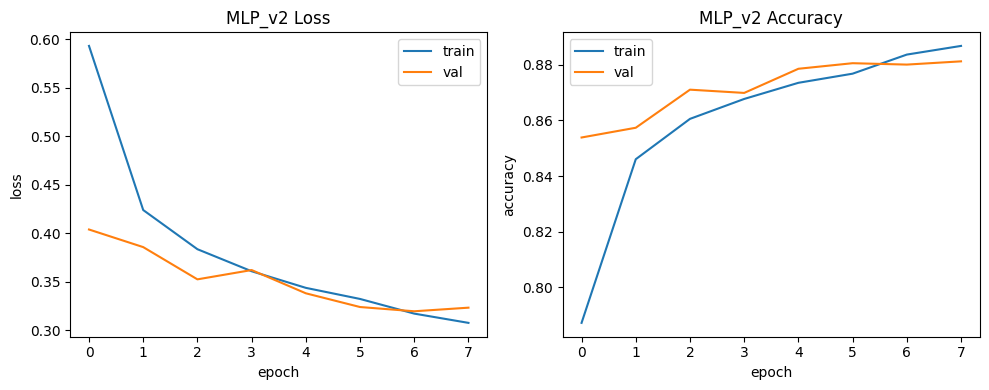

In [21]:
# ===== Графіки для MLP_v2 =====

def plot_history(hist, title_prefix=""):
    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(title_prefix + " Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(title_prefix + " Accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(history_mlp_v2, "MLP_v2")

In [22]:
# ===== 5) Покращений CNN =====
def build_cnn_v2(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.4),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ], name="CNN_v2")

    return model


cnn_v2 = build_cnn_v2()
cnn_v2.summary()

Model: "CNN_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
cnn_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn_v2 = cnn_v2.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=128,
    verbose=1
)

test_loss_cnn_v2, test_acc_cnn_v2 = cnn_v2.evaluate(x_test_cnn, y_test, verbose=0)
print("CNN_v2 test acc:", test_acc_cnn_v2)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.8036 - loss: 0.5517 - val_accuracy: 0.7930 - val_loss: 0.5828
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 0.8746 - loss: 0.3471 - val_accuracy: 0.8943 - val_loss: 0.2770
Epoch 3/8
385/422 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8874 - loss: 0.3076

KeyboardInterrupt: 

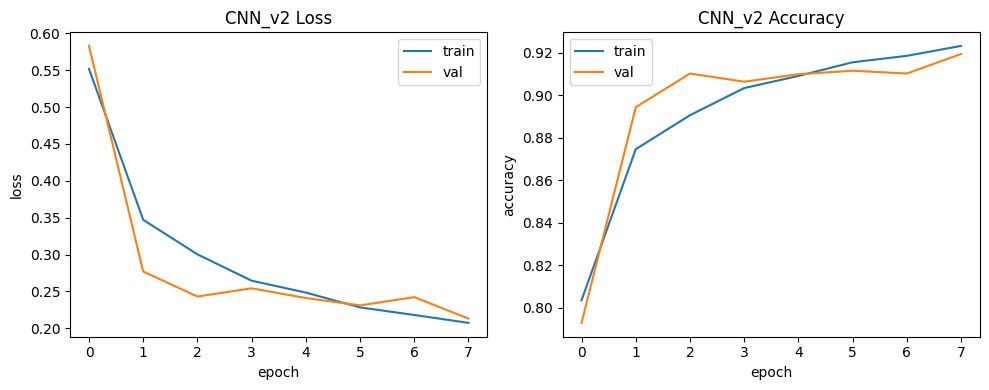

In [ ]:
plot_history(history_cnn_v2, "CNN_v2")

In [ ]:
# ===== 7) Порівняння оптимізаторів =====

cnn_sgd = build_cnn_v2()

cnn_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_sgd = cnn_sgd.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=128,
    verbose=1
)

test_loss_sgd, test_acc_sgd = cnn_sgd.evaluate(x_test_cnn, y_test, verbose=0)

print("Adam acc:", test_acc_cnn_v2)
print("SGD acc:", test_acc_sgd)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.7877 - loss: 0.5868 - val_accuracy: 0.8047 - val_loss: 0.5523
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.8585 - loss: 0.3874 - val_accuracy: 0.8852 - val_loss: 0.2972
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - accuracy: 0.8786 - loss: 0.3320 - val_accuracy: 0.8953 - val_loss: 0.2755
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - accuracy: 0.8871 - loss: 0.3051 - val_accuracy: 0.8822 - val_loss: 0.3039
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.8980 - loss: 0.2766 - val_accuracy: 0.8818 - val_loss: 0.3147
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.9029 - loss: 0.2646 - val_accuracy: 0.8917 - val_loss: 0.2934
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.9086 - loss: 0.2513 - val_accuracy: 0.8862 - val_loss: 0.2996
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.9100 - loss: 0.2401 - val_accu

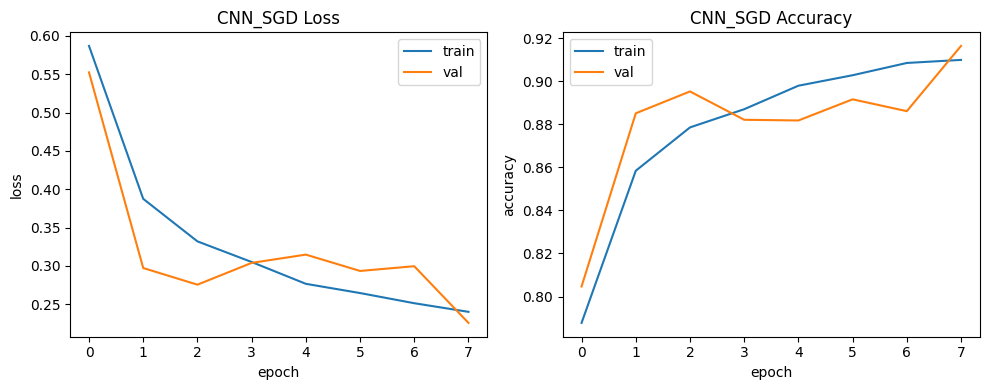

In [ ]:
plot_history(history_sgd, "CNN_SGD")

In [ ]:
# ===== 8) Аугментація =====

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

def build_cnn_aug():
    model = keras.Sequential([
        layers.Input(shape=(28,28,1)),
        data_augmentation,

        layers.Conv2D(32,3,padding="same",activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64,3,padding="same",activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128,activation="relu"),
        layers.Dense(10,activation="softmax")
    ])
    return model

cnn_aug = build_cnn_aug()

cnn_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug = cnn_aug.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=128
)

test_loss_aug, test_acc_aug = cnn_aug.evaluate(x_test_cnn, y_test, verbose=0)
print("CNN with augmentation acc:", test_acc_aug)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7254 - loss: 0.7532 - val_accuracy: 0.7788 - val_loss: 0.5842
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8097 - loss: 0.5166 - val_accuracy: 0.8353 - val_loss: 0.4805
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8310 - loss: 0.4591 - val_accuracy: 0.8480 - val_loss: 0.4237
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8456 - loss: 0.4205 - val_accuracy: 0.8577 - val_loss: 0.3951
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.8560 - loss: 0.3921 - val_accuracy: 0.8690 - val_loss: 0.3661
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8628 - loss: 0.3729 - val_accuracy: 0.8685 - val_loss: 0.3628
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8691 - loss: 0.3561 - val_accuracy: 0.8743 - val_loss: 0.3424
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8747 - loss: 0.3399 - val_accu

In [ ]:
# ===== 9) Batch size експеримент =====

for batch_size in [32, 256]:
    print("Batch size:", batch_size)

    model = build_cnn_v2()
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    model.fit(
        x_train_cnn, y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=batch_size,
        verbose=0
    )

    end = time.time()

    test_loss, test_acc = model.evaluate(x_test_cnn, y_test, verbose=0)

    print("Test acc:", test_acc)
    print("Time:", end - start)

Batch size: 32
Test acc: 0.9210000038146973
Time: 249.15811419487
Batch size: 256
Test acc: 0.9143999814987183
Time: 279.8024914264679


In [ ]:
# ===== 10) Fast CNN =====

def build_fast_cnn():
    model = keras.Sequential([
        layers.Input(shape=(28,28,1)),

        layers.Conv2D(32,3,padding="same",activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64,3,padding="same",activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(64,activation="relu"),
        layers.Dense(10,activation="softmax")
    ])
    return model

fast_cnn = build_fast_cnn()

fast_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start = time.time()

fast_cnn.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=6,
    batch_size=256,
    verbose=1
)

end = time.time()

test_loss_fast, test_acc_fast = fast_cnn.evaluate(x_test_cnn, y_test, verbose=0)

print("Fast CNN acc:", test_acc_fast)
print("Training time:", end - start)

Epoch 1/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7853 - loss: 0.6096 - val_accuracy: 0.8560 - val_loss: 0.4035
Epoch 2/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8685 - loss: 0.3702 - val_accuracy: 0.8807 - val_loss: 0.3388
Epoch 3/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8866 - loss: 0.3194 - val_accuracy: 0.8882 - val_loss: 0.3094
Epoch 4/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8971 - loss: 0.2908 - val_accuracy: 0.8927 - val_loss: 0.3028
Epoch 5/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9044 - loss: 0.2696 - val_accuracy: 0.8942 - val_loss: 0.3076
Epoch 6/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9097 - loss: 0.2524 - val_accuracy: 0.8935 - val_loss: 0.3062
Fast CNN acc: 0.8841000199317932
Training time: 52.07926654815674


In [ ]:
def count_params(model):
    return int(np.sum([np.prod(w.shape) for w in model.get_weights()]))

results = {
    "Model": [
        "MLP_v2",
        "CNN_v2 (Adam)",
        "CNN_v2 (SGD)",
        "CNN + Aug",
        "Fast CNN"
    ],
    "Params": [
        count_params(mlp_v2),
        count_params(cnn_v2),
        count_params(cnn_sgd),
        count_params(cnn_aug),
        count_params(fast_cnn)
    ],
    "Test Accuracy": [
        test_acc_mlp_v2,
        test_acc_cnn_v2,
        test_acc_sgd,
        test_acc_aug,
        test_acc_fast
    ]
}

df_results = pd.DataFrame(results)
df_results

,Model,Params,Test Accuracy
0,MLP_v2,468874,0.8754
1,CNN_v2 (Adam),242442,0.9166
2,CNN_v2 (SGD),242442,0.9107
3,CNN + Aug,421642,0.8629
4,Fast CNN,220234,0.8841


## Висновки

У цій роботі було порівняно дві моделі — MLP та CNN — для задачі класифікації зображень Fashion-MNIST.

Модель MLP_v2 мала 468 874 параметри та показала точність 87.54% на тестових даних. Навіть після збільшення кількості нейронів і додавання Dropout суттєвого покращення точності не відбулося. Це пов’язано з тим, що MLP не враховує просторову структуру зображення, а працює лише з набором чисел.

CNN_v2 з оптимізатором Adam показала кращий результат — 91.66% при меншій кількості параметрів (242 442). Це означає, що згорткова мережа ефективніше працює із зображеннями, оскільки аналізує їх структуру, виділяє контури та форми.

Порівняння Adam і SGD показало, що Adam дав трохи кращу точність (91.66% проти 91.07%) і швидше сходився під час навчання.

Аугментація в цьому випадку не покращила результат (86.29%), ймовірно через те, що зображення в датасеті прості та центровані.

Експеримент із batch size показав, що менший розмір батчу (32) дав найкращу точність — 92.10%, хоча навчання тривало довше. При batch size = 256 точність була трохи нижчою (91.44%).

Спрощена версія CNN навчалася швидше, але її точність (88.41%) була нижчою за повну CNN_v2.

Отже, для задач класифікації зображень CNN є більш ефективною моделлю, ніж MLP, оскільки вона краще враховує особливості зображень і забезпечує вищу точність.